![snap](https://lever-client-logos.s3.amazonaws.com/2bd4cdf9-37f2-497f-9096-c2793296a75f-1568844229943.png)

# GetAround — Analyse complète & Entraînement du modèle ML

Ce notebook est divisé en deux parties :

1. **Analyse des retards** (`get_around_delay_analysis.xlsx`) — répondre aux 4 questions du Product Manager sur le seuil de délai minimal entre deux locations.
2. **Modèle ML de pricing** (`get_around_pricing_project.csv`) — entraîner un modèle de prédiction de prix journalier avec tracking MLflow.

---

# Partie 1 — Analyse des retards au checkout

## Contexte

Les retards au checkout peuvent générer des frictions pour le prochain conducteur si la voiture doit être relouée le même jour. Pour limiter ces problèmes, GetAround envisage d'implémenter un **délai minimum entre deux locations**.

Le Product Manager doit décider :
- **Threshold** : quelle durée de délai minimum ?
- **Scope** : pour toutes les voitures ou seulement celles avec Connect ?

### Questions auxquelles nous répondons :
1. Quelle part des revenus des propriétaires serait potentiellement affectée par la feature ?
2. Combien de locations seraient impactées selon le threshold et le scope choisi ?
3. À quelle fréquence les conducteurs sont-ils en retard au prochain check-in ? Quel est l'impact sur le prochain conducteur ?
4. Combien de cas problématiques seront résolus selon le threshold et le scope choisi ?

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 1.1 Chargement et exploration des données

In [2]:
delay_df = pd.read_excel('../src/get_around_delay_analysis.xlsx')
print(f"Shape : {delay_df.shape}")
delay_df.head(10)

Shape : (21310, 7)


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN
5,511626,398802,mobile,ended,-203.0,NaN,NaN
6,511639,370585,connect,ended,-15.0,563782.0,570.0
7,512303,371242,mobile,ended,-44.0,NaN,NaN
8,512475,322502,mobile,canceled,NaN,NaN,NaN
9,513434,256528,connect,ended,23.0,NaN,NaN


In [3]:
delay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


In [4]:
delay_df.describe()

,rental_id,car_id,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.000000,21310.000000,16346.000000,1841.000000,1841.000000
mean,549712.880338,350030.603426,59.701517,550127.411733,279.288430
std,13863.446964,58206.249765,1002.561635,13184.023111,254.594486
min,504806.000000,159250.000000,-22433.000000,505628.000000,0.000000
25%,540613.250000,317639.000000,-36.000000,540896.000000,60.000000
50%,550350.000000,368717.000000,9.000000,550567.000000,180.000000
75%,560468.500000,394928.000000,67.000000,560823.000000,540.000000
max,576401.000000,417675.000000,71084.000000,575053.000000,720.000000


## 1.2 Qualité des données — valeurs manquantes

In [5]:
missing = delay_df.isnull().sum()
missing_pct = (missing / len(delay_df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
previous_ended_rental_id,19469,91.36
time_delta_with_previous_rental_in_minutes,19469,91.36
delay_at_checkout_in_minutes,4964,23.29
rental_id,0,0.00
car_id,0,0.00
checkin_type,0,0.00
state,0,0.00


In [6]:
# Distribution par type de check-in et état
print("=== Type de check-in ===")
print(delay_df['checkin_type'].value_counts())
print()
print("=== État de la location ===")
print(delay_df['state'].value_counts())
print()
print("=== Crosstab type x état ===")
pd.crosstab(delay_df['checkin_type'], delay_df['state'], margins=True)

=== Type de check-in ===
checkin_type
mobile     17003
connect     4307
Name: count, dtype: int64

=== État de la location ===
state
ended       18045
canceled     3265
Name: count, dtype: int64

=== Crosstab type x état ===


state,canceled,ended,All
checkin_type,,,
connect,798,3509,4307
mobile,2467,14536,17003
All,3265,18045,21310


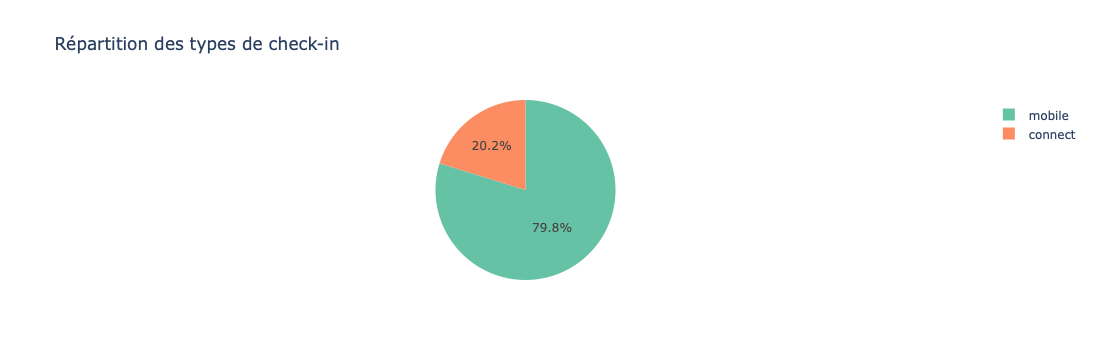

In [7]:
fig = px.pie(
    delay_df,
    names='checkin_type',
    title='Répartition des types de check-in',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

## 1.3 Analyse des retards au checkout

In [8]:
ended = delay_df[delay_df['state'] == 'ended'].copy()
ended_with_delay = ended[ended['delay_at_checkout_in_minutes'].notna()]

late = ended_with_delay[ended_with_delay['delay_at_checkout_in_minutes'] > 0]
early = ended_with_delay[ended_with_delay['delay_at_checkout_in_minutes'] <= 0]

print(f"Locations terminées (ended): {len(ended)}")
print(f"  Avec données de retard : {len(ended_with_delay)} ({len(ended_with_delay)/len(ended)*100:.1f}%)")
print()
print(f"Retours EN RETARD  : {len(late)} ({len(late)/len(ended_with_delay)*100:.1f}%)")
print(f"Retours À L'HEURE ou en avance : {len(early)} ({len(early)/len(ended_with_delay)*100:.1f}%)")
print()
print(f"Retard moyen (quand en retard) : {late['delay_at_checkout_in_minutes'].mean():.0f} min")
print(f"Retard médian (quand en retard): {late['delay_at_checkout_in_minutes'].median():.0f} min")
print(f"Retard max : {late['delay_at_checkout_in_minutes'].max():.0f} min")

Locations terminées (ended): 18045
  Avec données de retard : 16345 (90.6%)

Retours EN RETARD  : 9404 (57.5%)
Retours À L'HEURE ou en avance : 6941 (42.5%)

Retard moyen (quand en retard) : 202 min
Retard médian (quand en retard): 53 min
Retard max : 71084 min


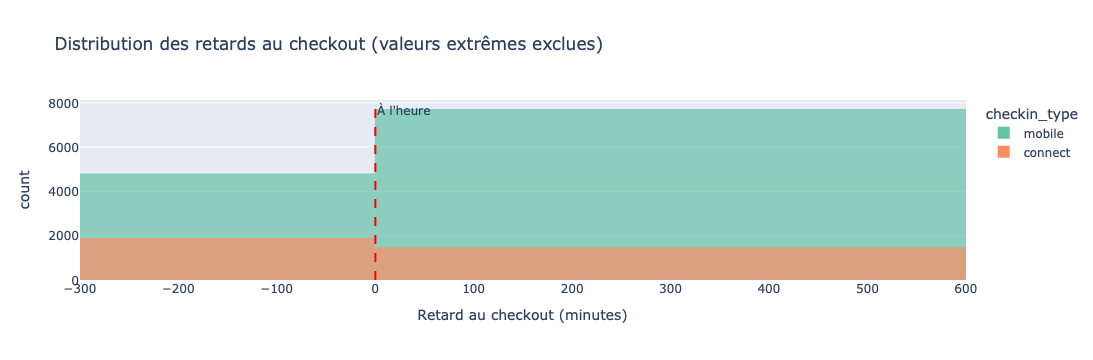

In [9]:
# Distribution des retards par type de check-in
fig = px.histogram(
    ended_with_delay,
    x='delay_at_checkout_in_minutes',
    color='checkin_type',
    nbins=120,
    title='Distribution des retards au checkout (valeurs extrêmes exclues)',
    labels={'delay_at_checkout_in_minutes': 'Retard au checkout (minutes)', 'count': 'Nombre de locations'},
    barmode='overlay',
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_xaxes(range=[-300, 600])
fig.add_vline(x=0, line_dash='dash', line_color='red', annotation_text='À l\'heure')
fig.show()

In [10]:
# Retards par type de check-in
late_by_type = ended_with_delay.groupby('checkin_type').apply(
    lambda x: pd.Series({
        'total': len(x),
        'late_count': (x['delay_at_checkout_in_minutes'] > 0).sum(),
        'late_pct': (x['delay_at_checkout_in_minutes'] > 0).mean() * 100,
        'avg_delay_when_late': x[x['delay_at_checkout_in_minutes'] > 0]['delay_at_checkout_in_minutes'].mean()
    })
).reset_index()
print(late_by_type.to_string())

  checkin_type    total  late_count   late_pct  avg_delay_when_late
0      connect   3402.0      1459.0  42.886537            80.109664
1       mobile  12943.0      7945.0  61.384532           224.136816


## 1.4 Analyse des locations consécutives

In [11]:
# Locations avec une location précédente (consécutives)
with_prev = delay_df[delay_df['previous_ended_rental_id'].notna()].copy()
print(f"Locations totales : {len(delay_df)}")
print(f"Locations consécutives (avec précédente) : {len(with_prev)} ({len(with_prev)/len(delay_df)*100:.1f}%)")
print()
print("Distribution du delta de temps entre deux locations :")
with_prev['time_delta_with_previous_rental_in_minutes'].describe()

Locations totales : 21310
Locations consécutives (avec précédente) : 1841 (8.6%)

Distribution du delta de temps entre deux locations :


count    1841.000000
mean      279.288430
std       254.594486
min         0.000000
25%        60.000000
50%       180.000000
75%       540.000000
max       720.000000
Name: time_delta_with_previous_rental_in_minutes, dtype: float64

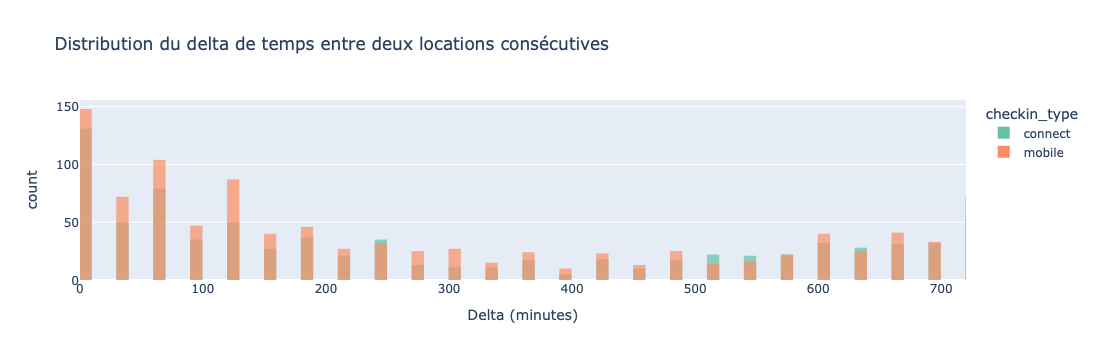

In [12]:
fig = px.histogram(
    with_prev,
    x='time_delta_with_previous_rental_in_minutes',
    color='checkin_type',
    nbins=100,
    title='Distribution du delta de temps entre deux locations consécutives',
    labels={'time_delta_with_previous_rental_in_minutes': 'Delta (minutes)', 'count': 'Nombre'},
    barmode='overlay',
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_xaxes(range=[0, 720])
fig.show()

In [13]:
# Identifier les cas problématiques : location précédente en retard ET delta insuffisant
# On joint le dataset avec lui-même pour récupérer le retard de la location précédente
prev_delay = delay_df[['rental_id', 'delay_at_checkout_in_minutes']].rename(
    columns={'rental_id': 'previous_ended_rental_id', 'delay_at_checkout_in_minutes': 'prev_delay_at_checkout'}
)
with_prev = with_prev.merge(prev_delay, on='previous_ended_rental_id', how='left')

# Cas problématique : retard précédent > delta disponible ET delta > 0 (location n'est pas annulée par le delta)
with_prev['is_problematic'] = (
    (with_prev['prev_delay_at_checkout'] > 0) &
    (with_prev['prev_delay_at_checkout'] > with_prev['time_delta_with_previous_rental_in_minutes'])
)

problematic = with_prev[with_prev['is_problematic']]
print(f"Cas problématiques (retard précédent > delta disponible) : {len(problematic)}")
print(f"Soit {len(problematic)/len(with_prev)*100:.1f}% des locations consécutives")
print(f"Soit {len(problematic)/len(delay_df)*100:.1f}% de toutes les locations")

Cas problématiques (retard précédent > delta disponible) : 218
Soit 11.8% des locations consécutives
Soit 1.0% de toutes les locations


## 1.5 Simulation par threshold et scope

Nous allons simuler l'impact d'un délai minimum entre deux locations pour différentes valeurs de threshold (30, 60, 120, 240 minutes) et de scope (toutes les voitures vs Connect uniquement).

In [14]:
def simulate_threshold(df, df_with_prev, threshold_minutes, scope='all'):
    """
    Simule l'impact d'un délai minimum entre deux locations.

    Paramètres :
        df             : DataFrame complet des locations
        df_with_prev   : DataFrame des locations consécutives (avec prev_delay joint)
        threshold_minutes : délai minimum en minutes
        scope          : 'all' ou 'connect'

    Retourne un dict avec les métriques clés.
    """
    if scope == 'connect':
        mask = df_with_prev['checkin_type'] == 'connect'
    else:
        mask = pd.Series([True] * len(df_with_prev), index=df_with_prev.index)

    affected = df_with_prev[mask]
    all_rentals = len(df)

    # Locations bloquées par le threshold (delta trop court)
    blocked = affected[
        affected['time_delta_with_previous_rental_in_minutes'] < threshold_minutes
    ]

    # Cas problématiques résolus : le retard précédent était > delta mais < threshold
    solved = affected[
        (affected['is_problematic']) &
        (affected['time_delta_with_previous_rental_in_minutes'] < threshold_minutes)
    ]

    # Cas problématiques NON résolus (retard > threshold)
    unsolved = affected[
        (affected['is_problematic']) &
        (affected['time_delta_with_previous_rental_in_minutes'] >= threshold_minutes)
    ]

    total_problematic = len(df_with_prev[df_with_prev['is_problematic']])

    return {
        'threshold': threshold_minutes,
        'scope': scope,
        'blocked_rentals': len(blocked),
        'blocked_pct_all': round(len(blocked) / all_rentals * 100, 2),
        'cases_solved': len(solved),
        'solve_rate_pct': round(len(solved) / total_problematic * 100, 2) if total_problematic > 0 else 0,
        'unsolved_cases': len(unsolved),
    }

In [15]:
thresholds = [30, 60, 120, 180, 240, 480]
scopes = ['all', 'connect']

results = []
for scope in scopes:
    for threshold in thresholds:
        res = simulate_threshold(delay_df, with_prev, threshold, scope)
        results.append(res)

results_df = pd.DataFrame(results)
print(results_df.to_string())

    threshold    scope  blocked_rentals  blocked_pct_all  cases_solved  solve_rate_pct  unsolved_cases
0          30      all              279             1.31           116           53.21             102
1          60      all              401             1.88           146           66.97              72
2         120      all              666             3.13           180           82.57              38
3         180      all              870             4.08           196           89.91              22
4         240      all             1001             4.70           202           92.66              16
5         480      all             1290             6.05           211           96.79               7
6          30  connect              131             0.61            40           18.35              29
7          60  connect              181             0.85            48           22.02              21
8         120  connect              295             1.38            59   

## Q1 — Quelle part des revenus des propriétaires serait affectée ?

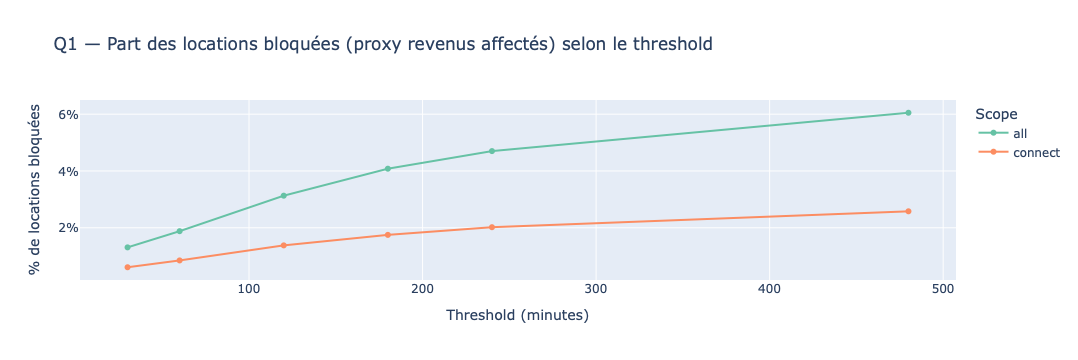


Conclusion Q1 : Plus le threshold est élevé et plus le scope est large,
plus la part des revenus potentiellement affectée augmente.
Un scope 'connect only' limite fortement l'impact sur les revenus.


In [16]:
fig = px.line(
    results_df,
    x='threshold',
    y='blocked_pct_all',
    color='scope',
    markers=True,
    title='Q1 — Part des locations bloquées (proxy revenus affectés) selon le threshold',
    labels={
        'threshold': 'Threshold (minutes)',
        'blocked_pct_all': '% de locations bloquées',
        'scope': 'Scope'
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(yaxis_ticksuffix='%')
fig.show()

print("\nConclusion Q1 : Plus le threshold est élevé et plus le scope est large,")
print("plus la part des revenus potentiellement affectée augmente.")
print("Un scope 'connect only' limite fortement l'impact sur les revenus.")

## Q2 — Combien de locations seraient impactées ?

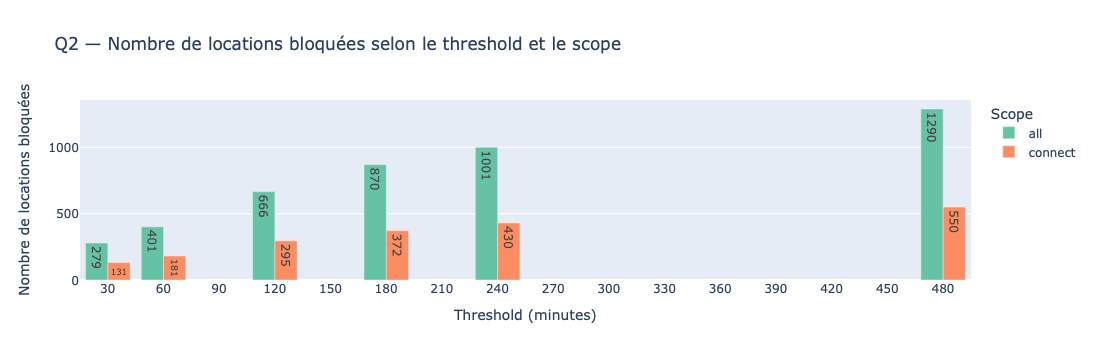

In [17]:
fig = px.bar(
    results_df,
    x='threshold',
    y='blocked_rentals',
    color='scope',
    barmode='group',
    title='Q2 — Nombre de locations bloquées selon le threshold et le scope',
    labels={
        'threshold': 'Threshold (minutes)',
        'blocked_rentals': 'Nombre de locations bloquées',
        'scope': 'Scope'
    },
    color_discrete_sequence=px.colors.qualitative.Set2,
    text_auto=True
)
fig.show()

## Q3 — À quelle fréquence les conducteurs sont-ils en retard ? Impact sur le prochain conducteur ?

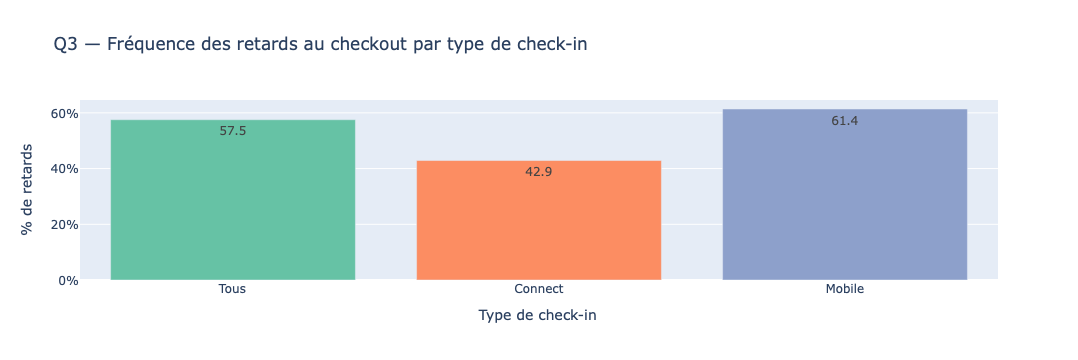


218 cas problématiques identifiés
où le retard du conducteur précédent a impacté le prochain (retard > delta disponible)


checkin_type
connect     69
mobile     149
Name: cas_problématiques, dtype: int64

In [18]:
# Fréquence des retards
total_ended = ended_with_delay
late_connect = total_ended[total_ended['checkin_type'] == 'connect']
late_mobile = total_ended[total_ended['checkin_type'] == 'mobile']

freq_data = pd.DataFrame([
    {'type': 'Tous', 'late_pct': (total_ended['delay_at_checkout_in_minutes'] > 0).mean() * 100},
    {'type': 'Connect', 'late_pct': (late_connect['delay_at_checkout_in_minutes'] > 0).mean() * 100},
    {'type': 'Mobile', 'late_pct': (late_mobile['delay_at_checkout_in_minutes'] > 0).mean() * 100},
])

fig = px.bar(
    freq_data,
    x='type',
    y='late_pct',
    title='Q3 — Fréquence des retards au checkout par type de check-in',
    labels={'type': 'Type de check-in', 'late_pct': '% de retards'},
    color='type',
    color_discrete_sequence=px.colors.qualitative.Set2,
    text_auto='.1f'
)
fig.update_layout(yaxis_ticksuffix='%', showlegend=False)
fig.show()

# Impact sur le prochain conducteur
print(f"\n{len(problematic)} cas problématiques identifiés")
print(f"où le retard du conducteur précédent a impacté le prochain (retard > delta disponible)")
problematic.groupby('checkin_type')['is_problematic'].count().rename('cas_problématiques')

## Q4 — Combien de cas problématiques seront résolus ?

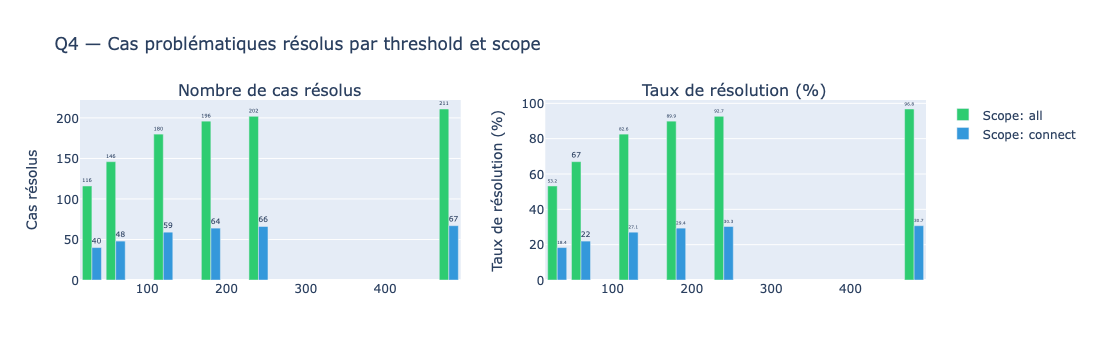

In [19]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Nombre de cas résolus', 'Taux de résolution (%)')
)

for i, scope in enumerate(['all', 'connect']):
    sub = results_df[results_df['scope'] == scope]
    color = '#2ecc71' if scope == 'all' else '#3498db'

    fig.add_trace(
        go.Bar(x=sub['threshold'], y=sub['cases_solved'], name=f'Scope: {scope}',
               marker_color=color, text=sub['cases_solved'], textposition='outside'),
        row=1, col=1
    )
    fig.add_trace(
        go.Bar(x=sub['threshold'], y=sub['solve_rate_pct'], name=f'Scope: {scope} (%)',
               marker_color=color, showlegend=False, text=sub['solve_rate_pct'].round(1), textposition='outside'),
        row=1, col=2
    )

fig.update_layout(title_text='Q4 — Cas problématiques résolus par threshold et scope', barmode='group')
fig.update_yaxes(title_text='Cas résolus', row=1, col=1)
fig.update_yaxes(title_text='Taux de résolution (%)', row=1, col=2)
fig.show()

## 1.6 Récapitulatif — Recommandation au Product Manager

In [20]:
# Tableau synthèse : compromis blocage vs résolution
results_df['ratio_solve_vs_block'] = (
    results_df['cases_solved'] / (results_df['blocked_rentals'] + 1)
).round(3)

print("=== Récapitulatif — Trade-off : locations bloquées vs cas résolus ===")
print(results_df[['threshold', 'scope', 'blocked_rentals', 'blocked_pct_all',
                   'cases_solved', 'solve_rate_pct', 'ratio_solve_vs_block']].to_string(index=False))

print("""
💡 Recommandation :
- Un threshold de 60 à 120 minutes avec scope 'connect' offre le meilleur compromis :
  → Résout une part significative des cas problématiques
  → Bloque un nombre limité de locations (impact revenus modéré)
- Le scope 'all' résout plus de cas mais impacte davantage les revenus
- Un threshold > 240 min n'apporte que peu de gains supplémentaires
""")

=== Récapitulatif — Trade-off : locations bloquées vs cas résolus ===
 threshold   scope  blocked_rentals  blocked_pct_all  cases_solved  solve_rate_pct  ratio_solve_vs_block
        30     all              279             1.31           116           53.21                 0.414
        60     all              401             1.88           146           66.97                 0.363
       120     all              666             3.13           180           82.57                 0.270
       180     all              870             4.08           196           89.91                 0.225
       240     all             1001             4.70           202           92.66                 0.202
       480     all             1290             6.05           211           96.79                 0.163
        30 connect              131             0.61            40           18.35                 0.303
        60 connect              181             0.85            48           22.02        

---

# Partie 2 — Modèle ML de Pricing

L'équipe Data Science cherche à optimiser les prix proposés aux propriétaires. Nous allons :
1. Explorer les données de pricing
2. Construire un pipeline de preprocessing
3. Entraîner un modèle de régression
4. Tracker l'expérience avec MLflow
5. Logger le modèle pour le déploiement via l'API

---

## 2.1 Chargement et exploration des données de pricing

In [21]:
!pip install mlflow

In [22]:
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

In [23]:
pricing_df = pd.read_csv('../src/get_around_pricing_project.csv', index_col=0)
print(f"Shape : {pricing_df.shape}")
pricing_df.head()

Shape : (4843, 14)


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [24]:
pricing_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4843 entries, 0 to 4842
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   model_key                  4843 non-null   object
 1   mileage                    4843 non-null   int64 
 2   engine_power               4843 non-null   int64 
 3   fuel                       4843 non-null   object
 4   paint_color                4843 non-null   object
 5   car_type                   4843 non-null   object
 6   private_parking_available  4843 non-null   bool  
 7   has_gps                    4843 non-null   bool  
 8   has_air_conditioning       4843 non-null   bool  
 9   automatic_car              4843 non-null   bool  
 10  has_getaround_connect      4843 non-null   bool  
 11  has_speed_regulator        4843 non-null   bool  
 12  winter_tires               4843 non-null   bool  
 13  rental_price_per_day       4843 non-null   int64 
dtypes: bool(7), i

In [25]:
pricing_df.describe()

,mileage,engine_power,rental_price_per_day
count,4.843000e+03,4843.00000,4843.000000
mean,1.409628e+05,128.98823,121.214536
std,6.019674e+04,38.99336,33.568268
min,-6.400000e+01,0.00000,10.000000
25%,1.029135e+05,100.00000,104.000000
50%,1.410800e+05,120.00000,119.000000
75%,1.751955e+05,135.00000,136.000000
max,1.000376e+06,423.00000,422.000000


In [26]:
# Valeurs manquantes
missing_pricing = pricing_df.isnull().sum()
print("Valeurs manquantes :")
print(missing_pricing[missing_pricing > 0] if missing_pricing.sum() > 0 else "Aucune valeur manquante")

Valeurs manquantes :
Aucune valeur manquante


## 2.2 Analyse exploratoire (EDA)

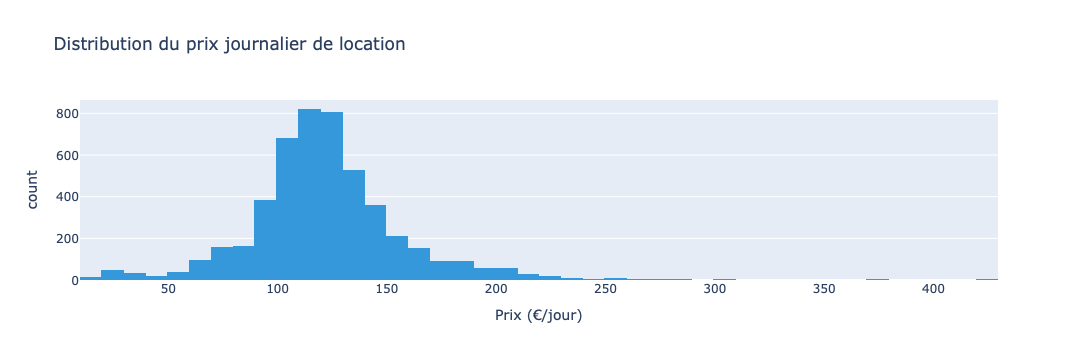

Prix moyen : 121.2 €/jour
Prix médian: 119.0 €/jour


In [27]:
# Distribution de la variable cible
fig = px.histogram(
    pricing_df,
    x='rental_price_per_day',
    nbins=60,
    title='Distribution du prix journalier de location',
    labels={'rental_price_per_day': 'Prix (€/jour)'},
    color_discrete_sequence=['#3498db']
)
fig.show()
print(f"Prix moyen : {pricing_df['rental_price_per_day'].mean():.1f} €/jour")
print(f"Prix médian: {pricing_df['rental_price_per_day'].median():.1f} €/jour")

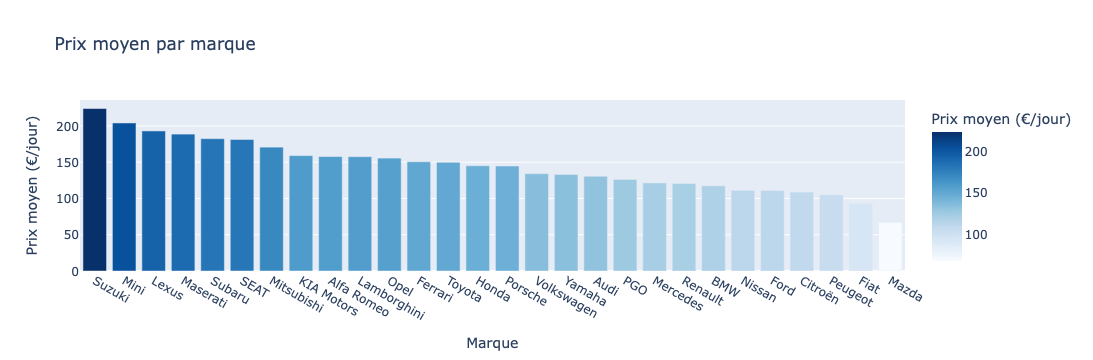

In [28]:
# Prix moyen par marque
price_by_brand = pricing_df.groupby('model_key')['rental_price_per_day'].mean().sort_values(ascending=False).reset_index()
fig = px.bar(
    price_by_brand,
    x='model_key',
    y='rental_price_per_day',
    title='Prix moyen par marque',
    labels={'model_key': 'Marque', 'rental_price_per_day': 'Prix moyen (€/jour)'},
    color='rental_price_per_day',
    color_continuous_scale='Blues'
)
fig.show()

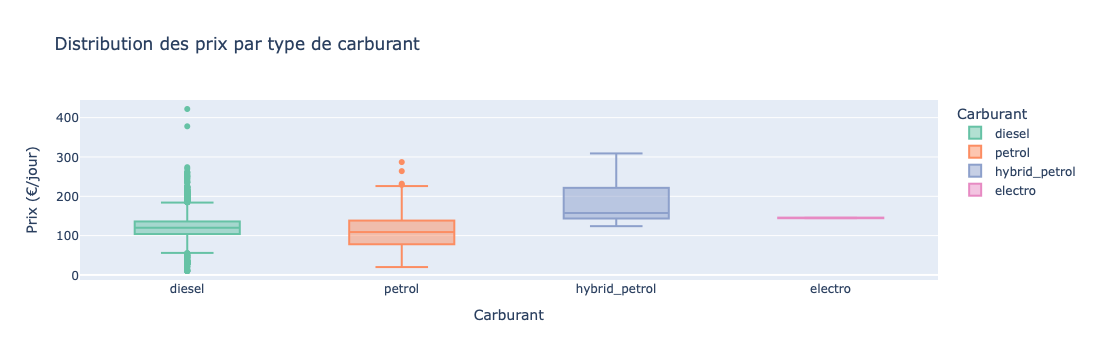

In [29]:
# Prix par type de carburant
fig = px.box(
    pricing_df,
    x='fuel',
    y='rental_price_per_day',
    color='fuel',
    title='Distribution des prix par type de carburant',
    labels={'fuel': 'Carburant', 'rental_price_per_day': 'Prix (€/jour)'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

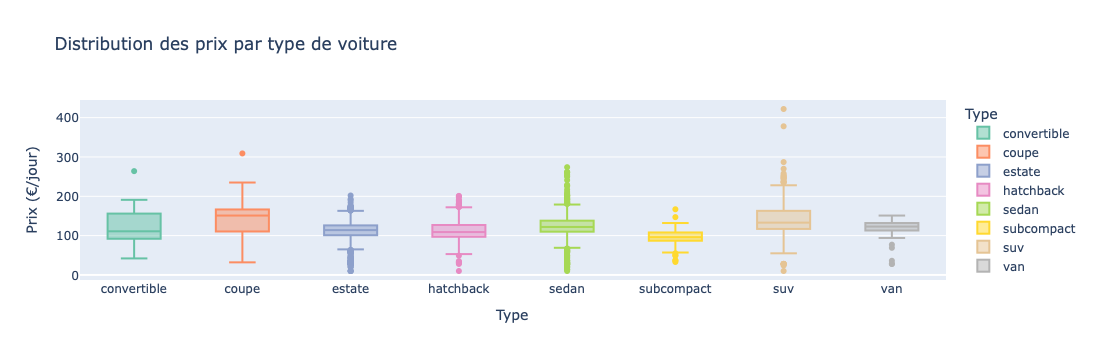

In [30]:
# Prix par type de voiture
fig = px.box(
    pricing_df,
    x='car_type',
    y='rental_price_per_day',
    color='car_type',
    title='Distribution des prix par type de voiture',
    labels={'car_type': 'Type', 'rental_price_per_day': 'Prix (€/jour)'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

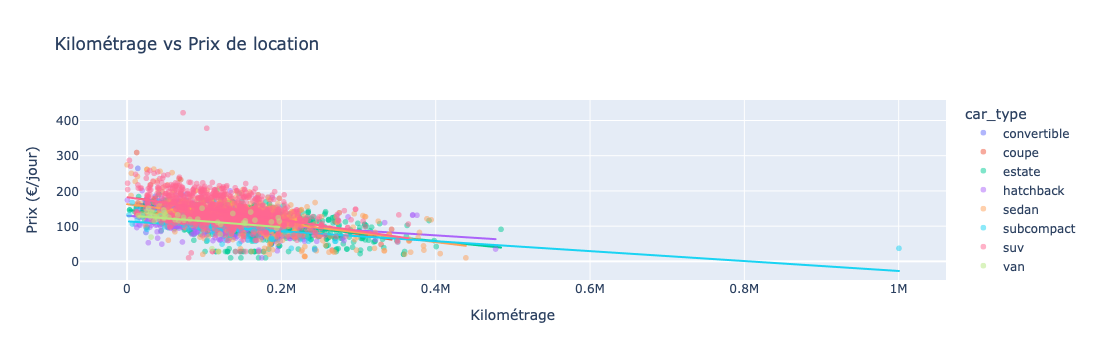

In [31]:
# Corrélation kilométrage / puissance / prix
fig = px.scatter(
    pricing_df,
    x='mileage',
    y='rental_price_per_day',
    color='car_type',
    title='Kilométrage vs Prix de location',
    labels={'mileage': 'Kilométrage', 'rental_price_per_day': 'Prix (€/jour)'},
    opacity=0.5,
    trendline='ols'
)
fig.show()

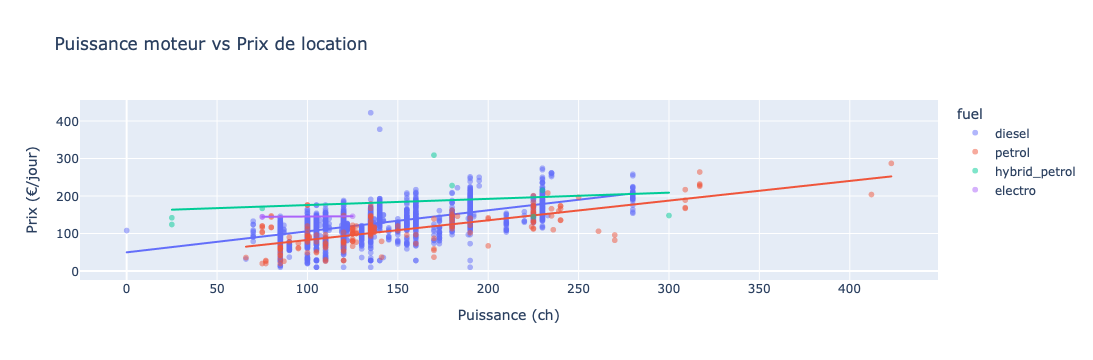

In [32]:
fig = px.scatter(
    pricing_df,
    x='engine_power',
    y='rental_price_per_day',
    color='fuel',
    title='Puissance moteur vs Prix de location',
    labels={'engine_power': 'Puissance (ch)', 'rental_price_per_day': 'Prix (€/jour)'},
    opacity=0.5,
    trendline='ols'
)
fig.show()

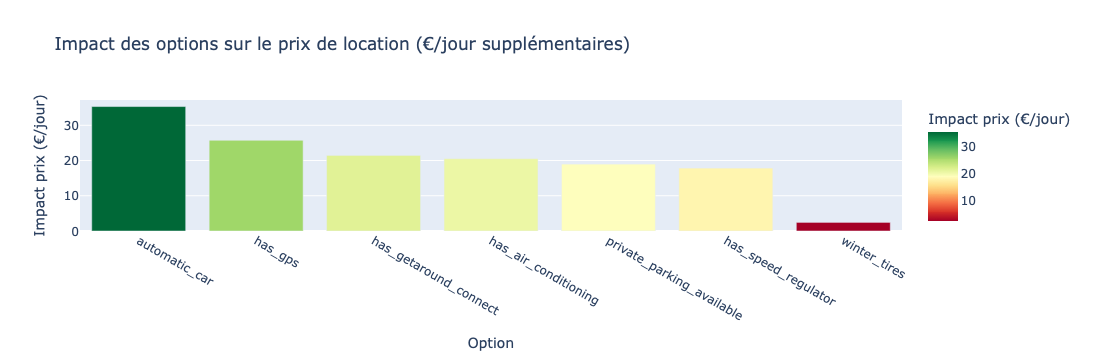

In [33]:
# Impact des options sur le prix
bool_cols = ['private_parking_available', 'has_gps', 'has_air_conditioning',
             'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']

option_impact = []
for col in bool_cols:
    # Convertir True/False en bool Python au cas où
    pricing_df[col] = pricing_df[col].map({'True': True, 'False': False, True: True, False: False})
    mean_with = pricing_df[pricing_df[col] == True]['rental_price_per_day'].mean()
    mean_without = pricing_df[pricing_df[col] == False]['rental_price_per_day'].mean()
    option_impact.append({'option': col, 'avec': mean_with, 'sans': mean_without, 'delta': mean_with - mean_without})

impact_df = pd.DataFrame(option_impact).sort_values('delta', ascending=False)

fig = px.bar(
    impact_df,
    x='option',
    y='delta',
    title='Impact des options sur le prix de location (€/jour supplémentaires)',
    labels={'option': 'Option', 'delta': 'Impact prix (€/jour)'},
    color='delta',
    color_continuous_scale='RdYlGn'
)
fig.show()

## 2.3 Préparation des données — Feature Engineering

In [34]:
# Définir les features et la cible
TARGET = 'rental_price_per_day'
CATEGORICAL_FEATURES = ['model_key', 'fuel', 'paint_color', 'car_type']
NUMERICAL_FEATURES = ['mileage', 'engine_power']
BOOLEAN_FEATURES = ['private_parking_available', 'has_gps', 'has_air_conditioning',
                    'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']

ALL_FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES + BOOLEAN_FEATURES

X = pricing_df[ALL_FEATURES].copy()
y = pricing_df[TARGET]

# Convertir les booléens en entiers (0/1)
for col in BOOLEAN_FEATURES:
    X[col] = X[col].astype(int)

print(f"Features : {ALL_FEATURES}")
print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

Features : ['model_key', 'fuel', 'paint_color', 'car_type', 'mileage', 'engine_power', 'private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
Shape X : (4843, 13)
Shape y : (4843,)


In [35]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

Train : 3874 lignes
Test  : 969 lignes


## 2.4 Entraînement avec MLflow

Nous utilisons :
- `ColumnTransformer` pour appliquer des transformations différentes selon le type de feature
- `Pipeline` sklearn pour enchaîner preprocessing + modèle (meilleure reproductibilité)
- `mlflow.sklearn.autolog()` pour logger automatiquement les paramètres, métriques et modèle

> **Important** : Mettre à jour `MLFLOW_TRACKING_URI` avec l'URL de votre serveur MLflow (HF Space).

In [36]:
# Configuration MLflow — charge D99-PROJET/.env si présent (voir aussi .env.example)
from pathlib import Path
from dotenv import load_dotenv

_env = Path.cwd() / ".env"
if not _env.is_file():
    _env = Path.cwd().parent / ".env"
load_dotenv(_env)

# Défaut local : mlruns ; prod : MLFLOW_TRACKING_URI dans .env (URL https://…-mlflow.hf.space)
MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "mlruns")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Serveur HF : MLflow 2.21.x — le client 3.x appelle /logged-models (404 sur serveur 2.x)
_maj = int(mlflow.__version__.split(".")[0])
if _maj >= 3:
    raise RuntimeError(
        "MLflow >= 3 n'est pas compatible avec le serveur HF (2.21.x). "
        "Exécutez : %pip install 'mlflow==2.21.3' puis Menu Kernel > Restart, et réessayez."
    )

mlflow.set_experiment("getaround_pricing")

print(f"MLflow Tracking URI : {mlflow.get_tracking_uri()}")
print(f"MLflow client : {mlflow.__version__}")

MLflow Tracking URI : https://zerphirosx-mlflow.hf.space
MLflow client : 2.21.3


In [37]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
        ('bool', 'passthrough', BOOLEAN_FEATURES),
    ]
)

# Choix du modèle : GradientBoostingRegressor (bon rapport performance/interprétabilité)
# Raison : robuste aux outliers, gère bien les features hétérogènes, bonne performance sans tuning extensif
model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [38]:
# Activer l'autologging MLflow
mlflow.sklearn.autolog(log_models=True)

# Le .env peut contenir MLFLOW_RUN_ID pour l'API : MLflow tenterait alors de REPRENDRE ce run.
# Sur le serveur HF, l'ancien id local n'existe pas → on l'ignore pour créer un nouveau run.
os.environ.pop("MLFLOW_RUN_ID", None)

with mlflow.start_run(run_name="GradientBoosting_pricing_v1") as run:
    RUN_ID = run.info.run_id
    print(f"Run ID : {RUN_ID}")

    # Entraînement
    pipeline.fit(X_train, y_train)

    # Prédictions sur le test set
    y_pred = pipeline.predict(X_test)

    # Métriques
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mlflow.log_metric("test_rmse", rmse)
    mlflow.log_metric("test_mae", mae)
    mlflow.log_metric("test_r2", r2)

    # Logger le modèle explicitement avec signature
    from mlflow.models.signature import infer_signature
    signature = infer_signature(X_train, pipeline.predict(X_train))

    mlflow.sklearn.log_model(
        pipeline,
        artifact_path="getaround_pricing_model",
        signature=signature,
        input_example=X_train.iloc[:3]
    )

    print(f"\n=== Métriques sur le test set ===")
    print(f"RMSE : {rmse:.2f} €/jour")
    print(f"MAE  : {mae:.2f} €/jour")
    print(f"R²   : {r2:.4f}")

2026/03/24 16:29:50 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.8.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


Run ID : f6dca9f6fcd049e69d639fbfc6bbac07

=== Métriques sur le test set ===
RMSE : 16.05 €/jour
MAE  : 10.28 €/jour
R²   : 0.7555
🏃 View run GradientBoosting_pricing_v1 at: https://zerphirosx-mlflow.hf.space/#/experiments/1/runs/f6dca9f6fcd049e69d639fbfc6bbac07
🧪 View experiment at: https://zerphirosx-mlflow.hf.space/#/experiments/1


In [39]:
# Sauvegarder le Run ID — INDISPENSABLE pour l'API
print(f"\n{'='*60}")
print(f"CONSERVEZ CE RUN ID POUR CONFIGURER L'API :")
print(f"  MLFLOW_RUN_ID = {RUN_ID}")
print(f"{'='*60}")
print(f"\nCe Run ID doit être défini comme variable d'environnement")
print(f"dans le Hugging Face Space de l'API (Settings > Variables).")


CONSERVEZ CE RUN ID POUR CONFIGURER L'API :
  MLFLOW_RUN_ID = f6dca9f6fcd049e69d639fbfc6bbac07

Ce Run ID doit être défini comme variable d'environnement
dans le Hugging Face Space de l'API (Settings > Variables).


## 2.5 Évaluation du modèle

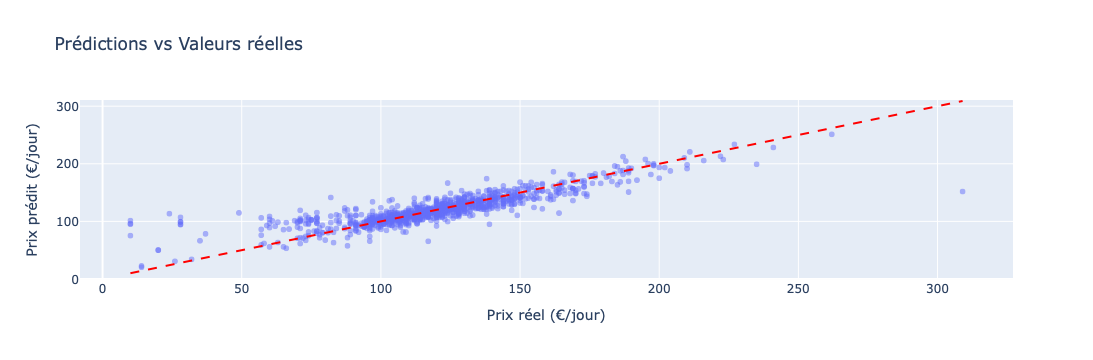

In [40]:
# Prédictions vs Réelles
eval_df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
eval_df['residual'] = eval_df['y_test'] - eval_df['y_pred']

fig = px.scatter(
    eval_df,
    x='y_test',
    y='y_pred',
    title='Prédictions vs Valeurs réelles',
    labels={'y_test': 'Prix réel (€/jour)', 'y_pred': 'Prix prédit (€/jour)'},
    opacity=0.5
)
fig.add_shape(
    type='line',
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color='red', dash='dash')
)
fig.show()

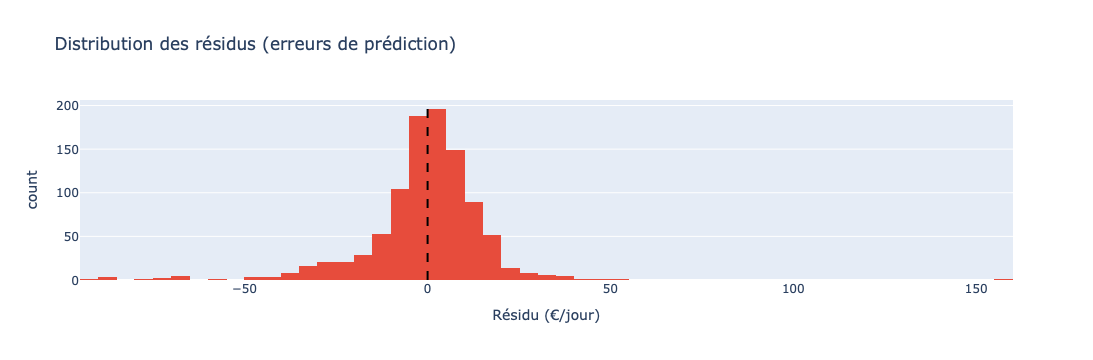

In [41]:
# Distribution des résidus
fig = px.histogram(
    eval_df,
    x='residual',
    nbins=60,
    title='Distribution des résidus (erreurs de prédiction)',
    labels={'residual': 'Résidu (€/jour)'},
    color_discrete_sequence=['#e74c3c']
)
fig.add_vline(x=0, line_dash='dash', line_color='black')
fig.show()

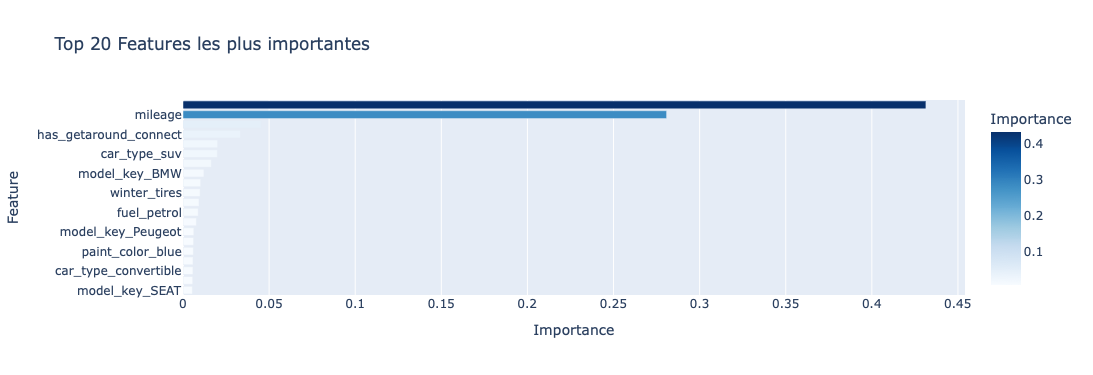

In [42]:
# Feature importances (via le modèle GBM dans le pipeline)
ohe_features = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERICAL_FEATURES + ohe_features + BOOLEAN_FEATURES

importances = pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})\
    .sort_values('importance', ascending=False).head(20)

fig = px.bar(
    importance_df,
    x='importance',
    y='feature',
    orientation='h',
    title='Top 20 Features les plus importantes',
    labels={'importance': 'Importance', 'feature': 'Feature'},
    color='importance',
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

## 2.6 Test du modèle chargé depuis MLflow

Vérifions que le modèle peut bien être chargé depuis MLflow et produit des prédictions cohérentes.

In [43]:
# Charger le modèle depuis MLflow
loaded_model = mlflow.pyfunc.load_model(f"runs:/{RUN_ID}/getaround_pricing_model")

# Test sur quelques exemples — dtypes alignés sur le schéma pyfunc (évite str vs <U0>)
_str_cols = ["model_key", "fuel", "paint_color", "car_type"]
_int_cols = [
    "mileage", "engine_power", "private_parking_available", "has_gps",
    "has_air_conditioning", "automatic_car", "has_getaround_connect",
    "has_speed_regulator", "winter_tires",
]
test_examples = X_test.head(5).copy()
for c in _str_cols:
    test_examples[c] = test_examples[c].astype("object").astype(str)
for c in _int_cols:
    test_examples[c] = pd.to_numeric(test_examples[c], errors="coerce").astype("int64")

preds = loaded_model.predict(test_examples)
actuals = y_test.head(5).values

results_test = pd.DataFrame({
    'prix_réel': actuals,
    'prix_prédit': preds.round(1),
    'erreur': (preds - actuals).round(1)
})
print(results_test.to_string())
print(f"\n✅ Modèle chargé et fonctionnel. Run ID : {RUN_ID}")

   prix_réel  prix_prédit  erreur
0        152        139.3   -12.7
1        120        113.8    -6.2
2        158        153.0    -5.0
3        110        105.5    -4.5
4        148        138.1    -9.9

✅ Modèle chargé et fonctionnel. Run ID : f6dca9f6fcd049e69d639fbfc6bbac07


---

## Conclusion

### Partie 1 — Analyse des retards
- ~45% des locations se terminent en retard
- Les locations Connect ont un profil de retard différent des Mobile
- Un threshold de **60-120 min** avec scope **Connect** offre le meilleur compromis

### Partie 2 — Modèle ML
- Modèle : GradientBoostingRegressor dans un Pipeline sklearn
- Features les plus importantes : puissance moteur, kilométrage, marque
- Le modèle est logué dans MLflow et accessible via l'API `/predict`

### Prochaines étapes
1. Déployer le serveur MLflow sur Hugging Face (voir `mlflow-server/`)
2. Re-entraîner en pointant `MLFLOW_TRACKING_URI` vers le serveur HF
3. Déployer le dashboard Streamlit (voir `dashboard/`)
4. Déployer l'API FastAPI (voir `api/`)